In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [5]:
def getCSV(csv):
    dfl = pd.read_csv(csv)
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\Foreign_births.csv') 
print(df)
print(set(df["Nationality of Both Parents"].tolist()))

              Statistic Label  Year  \
0            Number of Births  2011   
1            Number of Births  2011   
2            Number of Births  2011   
3            Number of Births  2011   
4            Number of Births  2011   
..                        ...   ...   
671  Percentage of all Births  2023   
672  Percentage of all Births  2023   
673  Percentage of all Births  2023   
674  Percentage of all Births  2023   
675  Percentage of all Births  2023   

                           Nationality of Both Parents    UNIT    VALUE  
0                                    All nationalities  Number  74033.0  
1                                   Both parents Irish  Number  39496.0  
2                             Mother Irish & Father UK  Number   1105.0  
3    Mother Irish & Father EU15 excluding Irish and UK  Number    305.0  
4             Mother Irish & Father EU16 - EU27 states  Number    349.0  
..                                                 ...     ...      ...  
671  Mother I

In [27]:
filtered_df = df[df["UNIT"]=="%"]
m_other = "Mother other & Father Irish"
f_other = "Mother Irish & Father other"
other = "Mother & Father other"
other_df = filtered_df[filtered_df['Nationality of Both Parents']==other]
m_other_df = filtered_df[filtered_df['Nationality of Both Parents']==m_other]
f_other_df = filtered_df[filtered_df['Nationality of Both Parents']==f_other]

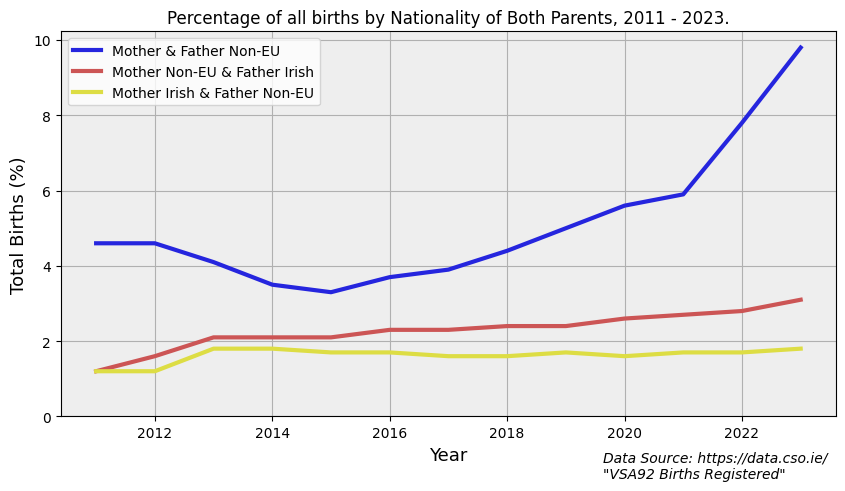

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

other_df.plot(x="Year", y="VALUE", kind="line", marker="None", linestyle="-", color="#2525DE", linewidth=3, ax=ax, label="Mother & Father Non-EU")
m_other_df.plot(x="Year", y="VALUE", kind="line", marker="None", linestyle="-", color="#C55", linewidth=3, ax=ax, label="Mother Non-EU & Father Irish")
f_other_df.plot(x="Year", y="VALUE", kind="line", marker="None", linestyle="-", color="#DD4", linewidth=3, ax=ax, label="Mother Irish & Father Non-EU")

title_string = "Percentage of all births by Nationality of Both Parents, 2011 - 2023."

plt.title(title_string)
plt.xlabel('Year', fontsize=13)
plt.ylabel('Total Births (%)', fontsize=13)
ax.set_ylim(0)
ax.set_facecolor('#EEEEEE') 
plt.grid(True)

plt.text(0.7, -0.16, "Data Source: https://data.cso.ie/\n\"VSA92 Births Registered\" ", ha='left',
         transform=ax.transAxes, fontdict={'fontstyle': 'italic', 'fontsize': 10})

save_fig = 'Births-'+m_other+f_other+"-"+other+'.png'
plt.savefig(save_fig, bbox_inches="tight")

# Show the plot
plt.show()